## Import Libraries

In [1]:
import pandas as pd
import numpy as np

# visualizations
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# train test split
from sklearn.model_selection import train_test_split

# ML algorithms
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

# scalers
from sklearn.preprocessing import MinMaxScaler, StandardScaler

## Loading the Dataset

In [2]:
df = pd.read_csv("./covertype.csv")
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


## Cleaning the data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Unnamed: 0                          581012 non-null  int64
 1   Unnamed: 1                          581012 non-null  int64
 2   Unnamed: 2                          581012 non-null  int64
 3   Elevation                           581012 non-null  int64
 4   Aspect                              581012 non-null  int64
 5   Slope                               581012 non-null  int64
 6   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 7   Vertical_Distance_To_Hydrology      581012 non-null  int64
 8   Horizontal_Distance_To_Roadways     581012 non-null  int64
 9   Hillshade_9am                       581012 non-null  int64
 10  Hillshade_Noon                      581012 non-null  int64
 11  Hillshade_3pm                       581012 non-null 

In [4]:
df.isnull().sum()

Unnamed: 0                            0
Unnamed: 1                            0
Unnamed: 2                            0
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area                       0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11                           0


In [5]:
df.duplicated().sum()

np.int64(0)

## Making the train-test split

In [6]:
features = df.drop(columns = ["Cover_Type"])
target = df["Cover_Type"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.2, random_state = 23)

## First attemp to create the ML model (KNN)

In [8]:
knn = KNeighborsClassifier(n_neighbors=5)

In [9]:
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [10]:
# knn.score(X_test, y_test)
# 0.9689853101899263

A simple KNeighbors Classifier model scored a 0.97 accuracy. However, it took almost 10 min to run, so we are sampling the dataset in order to make the process smoother and make several tests. When we have the final results with the sample, we'll test them on the whole dataset.

The model is already super robust. So, here the goal may be to make it as accurate as possible doing some feature engineering. The following steps will be:

- Create the sample dataframe.
- Repeat the KNN model 
- Do some feature engineering
    - Scaling the data (normalizing and standarizing)
    - Removing columns that doesn't appear to be relevant
- Trying different models (linear regression, random forests...)
- Do the final tests with the complete dataset

## Creating the Sample

In [11]:
sample = df.sample(frac = 0.25, random_state = 23)
sample.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
47898,3247,340,7,808,72,4068,205,230,163,2605,...,0,0,0,0,0,0,0,0,0,1
517877,3171,299,14,210,30,228,180,234,194,2925,...,0,0,0,0,0,0,0,0,0,2
565292,2694,58,15,0,0,1537,230,208,108,1756,...,0,0,0,0,0,0,0,0,0,2
466882,2912,92,22,192,90,569,248,200,70,582,...,0,1,0,0,0,0,0,0,0,1
342855,3475,232,23,481,165,3488,177,253,206,1025,...,0,0,0,0,0,0,0,0,1,1


### Recreating the KNN test

I'll recreate it just to see if I have a similar result. If I get it, I'll consider the sample to be representative

#### Train Test Split

In [12]:
features = sample.drop(columns = ["Cover_Type"])
target = sample["Cover_Type"]

# we have overwritten the previous variables

In [13]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.2, random_state = 23)

# we have overwritten the previous variables

#### KNN test

In [14]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [15]:
knn.score(X_test, y_test)

0.9204846648996592

We'll consider this (0.9204846648996592) to be a good result. Enough to continue with the sample.

## Feature Engineering

### Scaling the Data

I'll create functions in order to ease the process as I don't know how many times I'll repeat this.

In [16]:
normalizer = MinMaxScaler()
normalizer.fit(X_train)

def normalized_df(X):
    X_norm = normalizer.transform(X)
    X_norm = pd.DataFrame(X_norm, columns = X.columns)
    return X_norm

standarizer = StandardScaler()
standarizer.fit(X_train)

def standarized_df(X):
    X_stan = standarizer.transform(X)
    X_stan = pd.DataFrame(X_stan, columns = X.columns)
    return X_stan

X_train_norm = normalized_df(X_train)
X_test_norm = normalized_df(X_test)
X_train_stan = standarized_df(X_train)
X_test_stan = standarized_df(X_test)

### Feature selection

In [17]:
df.columns

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Elevation', 'Aspect',
       'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area', 'Soil_Type1',
       'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6',
       'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10', 'Soil_Type11',
       'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15',
       'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19',
       'Soil_Type20', 'Soil_Type21', 'Soil_Type22', 'Soil_Type23',
       'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27',
       'Soil_Type28', 'Soil_Type29', 'Soil_Type30', 'Soil_Type31',
       'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35',
       'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39',
       'Soil_Type40', 'Cover_Type'],
 

<Axes: >

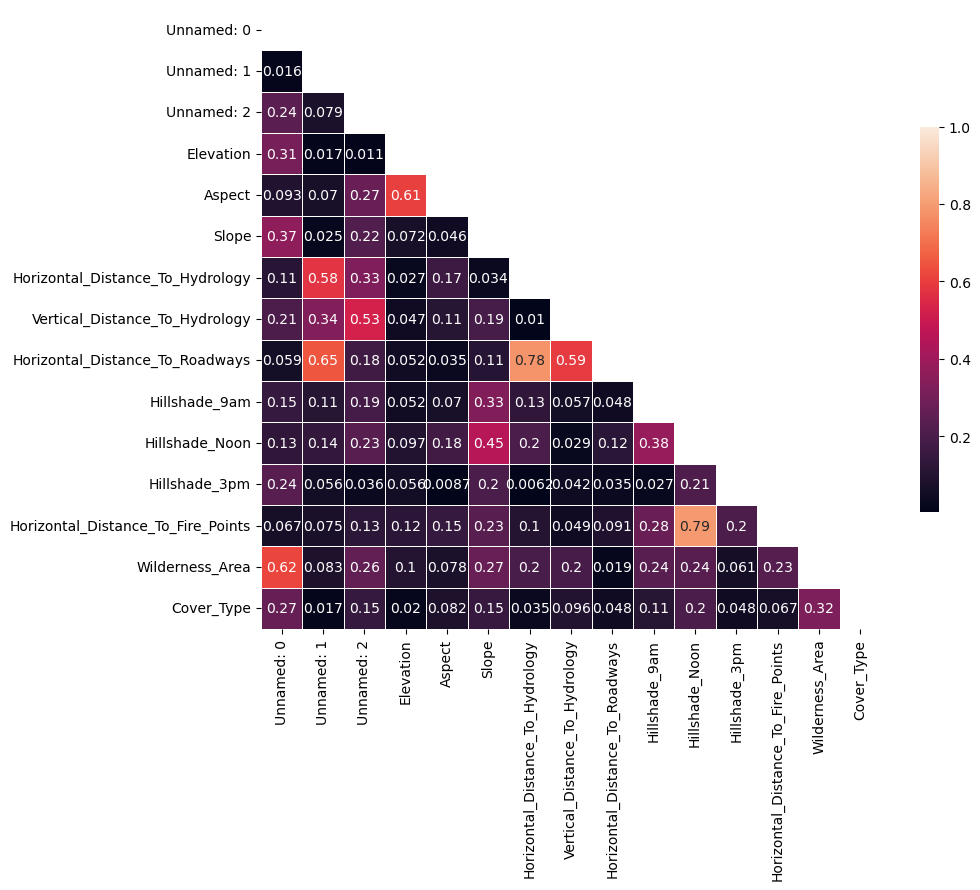

In [18]:
corr = np.abs(df.drop(columns = ['Soil_Type1',
       'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6',
       'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10', 'Soil_Type11',
       'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15',
       'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19',
       'Soil_Type20', 'Soil_Type21', 'Soil_Type22', 'Soil_Type23',
       'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27',
       'Soil_Type28', 'Soil_Type29', 'Soil_Type30', 'Soil_Type31',
       'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35',
       'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39',
       'Soil_Type40']).corr())
# dropping the soil types since they are one hot encoded and thus not useful for correlation analysis. 

#Set up mask for triangle representation
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(10, 10))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask,  vmax=1,square=True, linewidths=.5, cbar_kws={"shrink": .5},annot = corr)

I've decided to remove the unnamed columns as there is no clear metadata on them. Also, to avoid redundacy as they have a high correlation with other columns in the dataset like wilderness_area that, at the same time, has a higher correlation with cover_type. 

I'll also remove the all the distance ones ('Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Horizontal_Distance_To_Fire_Points'). The fire points one because of the correlation with hillshade_noon. The other three have little correlation with cover_type and some of them have high correlation between them. I'll try with none of them, if not, I'll include vertical_distance_to_roadways as it is the most related with cover_type.

In [19]:
def drop_columns(df):
    return df.drop(columns = ['Unnamed: 0', 
                       'Unnamed: 1', 
                       'Unnamed: 2', 
                       'Horizontal_Distance_To_Hydrology', 
                       'Vertical_Distance_To_Hydrology', 
                       'Horizontal_Distance_To_Roadways', 
                       'Horizontal_Distance_To_Fire_Points'])

X_train_norm_clean = drop_columns(X_train_norm)
X_test_norm_clean = drop_columns(X_test_norm)
X_train_stan_clean = drop_columns(X_train_stan)
X_test_stan_clean = drop_columns(X_test_stan)

# as we are doing two steps at the same time we'll include "control groups"

X_train_clean = drop_columns(X_train)
X_test_clean = drop_columns(X_test)

# when doing the testing, we'll include a test just with the sample not scaled, but dropping the columns.
# and another test with the scaled data, but all the columns. 

## KNN model

In [20]:
def knn_test (X_train, y_train, X_test, y_test):
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    return knn.score(X_test, y_test)

print("Accuracy without featuring engineering: ", round(knn_test(X_train, y_train, X_test, y_test), 2))
print("Accuracy dropping columns without scaling data: ", round(knn_test(X_train_clean, y_train, X_test_clean, y_test), 2))
print("\n")
print("Accuracy normalized data with all columns: ", round(knn_test(X_train_norm, y_train, X_test_norm, y_test), 2))
print("Accuracy standarized data with all columns: ", round(knn_test(X_train_stan, y_train, X_test_stan, y_test), 2))
print("\n")
print("Accuracy normalized data dropping columns: ", round(knn_test(X_train_norm_clean, y_train, X_test_norm_clean, y_test), 2))
print("Accuracy standarized data dropping columns: ", round(knn_test(X_train_stan_clean, y_train, X_test_stan_clean, y_test), 2))

Accuracy without featuring engineering:  0.92
Accuracy dropping columns without scaling data:  0.69


Accuracy normalized data with all columns:  0.89
Accuracy standarized data with all columns:  0.88


Accuracy normalized data dropping columns:  0.87
Accuracy standarized data dropping columns:  0.86


The first insights we get from this is that standarizing the data is giving us slightly worse results than normalizing the data. Anyway, both methods are worse than nothing.

Also, we can see that the more we manipulate the dataset the worse the result is. 
- Accuracy without featuring engineering:  0.92
- Accuracy normalized data with all columns:  0.89
- Accuracy normalized data dropping columns:  0.87
  
This indicates that whenever we take steps in order to simplify data and leave the most important part, we are losing relevant data. 



## Decision Tree model

In [21]:
def tree_test (X_train, y_train, X_test, y_test):
    tree = DecisionTreeClassifier(max_depth = 10)
    tree.fit(X_train, y_train)
    return tree.score(X_test, y_test)

print("Accuracy without featuring engineering: ", round(tree_test(X_train, y_train, X_test, y_test), 2))
print("Accuracy dropping columns without scaling data: ", round(tree_test(X_train_clean, y_train, X_test_clean, y_test), 2))
print("\n")
print("Accuracy normalized data with all columns: ", round(tree_test(X_train_norm, y_train, X_test_norm, y_test), 2))
print("Accuracy standarized data with all columns: ", round(tree_test(X_train_stan, y_train, X_test_stan, y_test), 2))
print("\n")
print("Accuracy normalized data dropping columns: ", round(tree_test(X_train_norm_clean, y_train, X_test_norm_clean, y_test), 2))
print("Accuracy standarized data dropping columns: ", round(tree_test(X_train_stan_clean, y_train, X_test_stan_clean, y_test), 2))

Accuracy without featuring engineering:  0.77
Accuracy dropping columns without scaling data:  0.66


Accuracy normalized data with all columns:  0.77
Accuracy standarized data with all columns:  0.77


Accuracy normalized data dropping columns:  0.66
Accuracy standarized data dropping columns:  0.66


## Random Forest

In [22]:
def random_forest(X_train, y_train, X_test, y_test):
    forest = RandomForestClassifier(n_estimators = 100, max_depth = 20)
    forest.fit(X_train, y_train)
    return forest.score(X_test, y_test)

print("Accuracy without featuring engineering: ", round(random_forest(X_train, y_train, X_test, y_test), 2))
print("Accuracy dropping columns without scaling data: ", round(random_forest(X_train_clean, y_train, X_test_clean, y_test), 2))
print("\n")
print("Accuracy normalized data with all columns: ", round(random_forest(X_train_norm, y_train, X_test_norm, y_test), 2))
print("Accuracy standarized data with all columns: ", round(random_forest(X_train_stan, y_train, X_test_stan, y_test), 2))
print("\n")
print("Accuracy normalized data dropping columns: ", round(random_forest(X_train_norm_clean, y_train, X_test_norm_clean, y_test), 2))
print("Accuracy standarized data dropping columns: ", round(random_forest(X_train_stan_clean, y_train, X_test_stan_clean, y_test), 2))

Accuracy without featuring engineering:  0.87
Accuracy dropping columns without scaling data:  0.8


Accuracy normalized data with all columns:  0.87
Accuracy standarized data with all columns:  0.87


Accuracy normalized data dropping columns:  0.79
Accuracy standarized data dropping columns:  0.79
